Loading data...


<ipython-input-3-0d2a38bbbf9f>:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Annual balance'].fillna(data['Annual balance'].mean(), inplace=True)


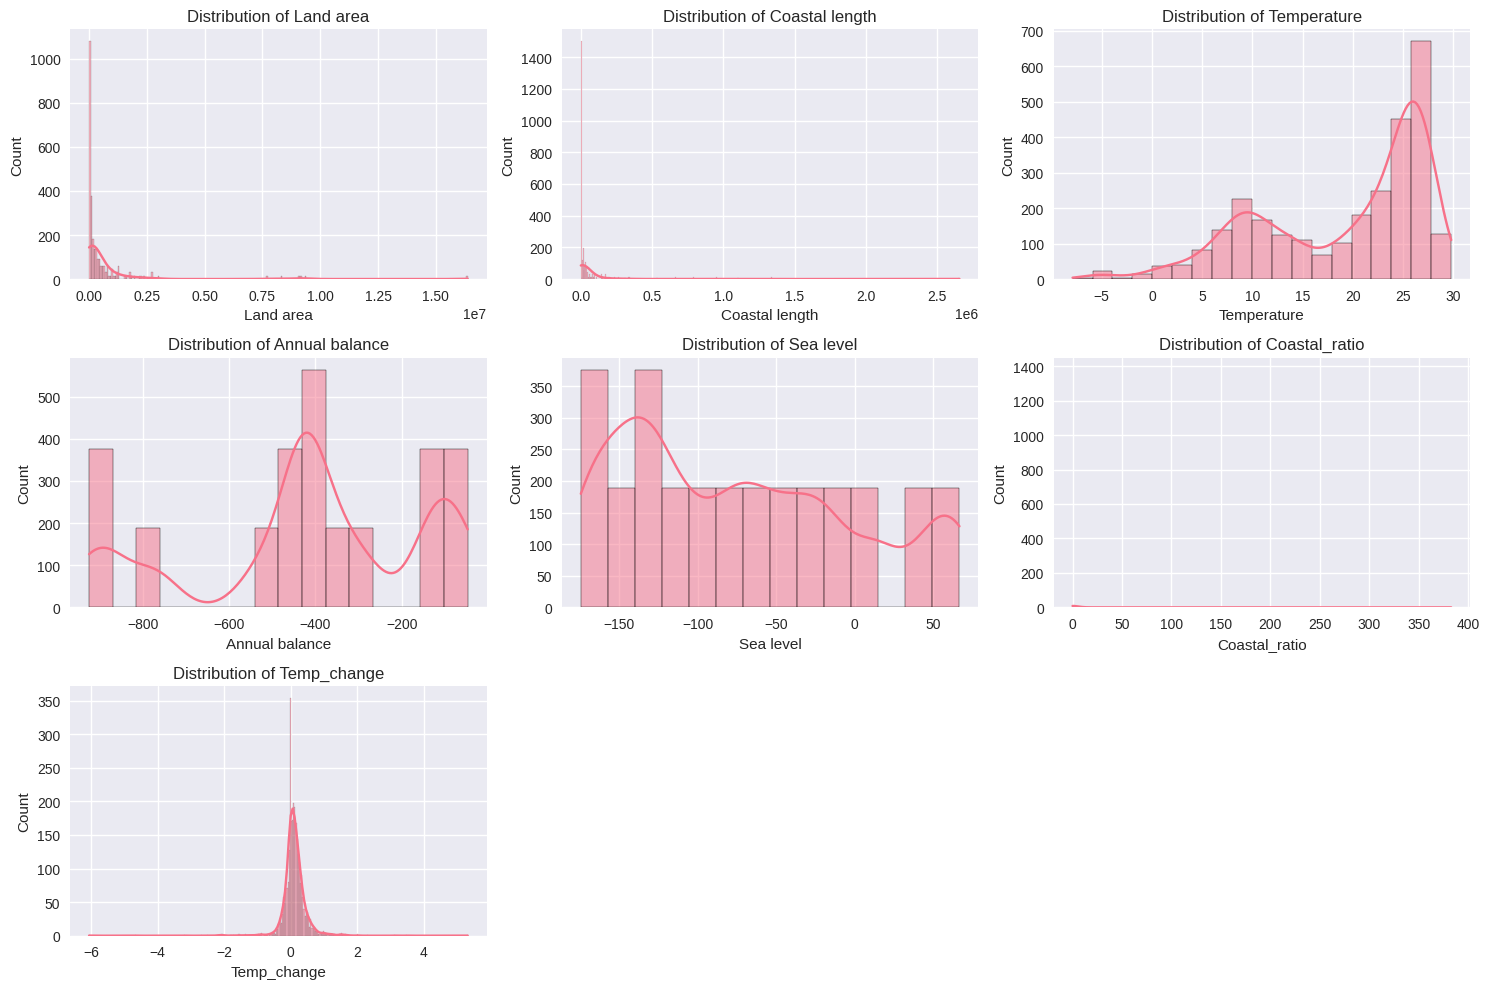

Saved feature distributions plot

Successfully processed 0/2820 images

Feature shapes: Tabular (2820, 7), Images (2820, 5), Combined (2820, 12)


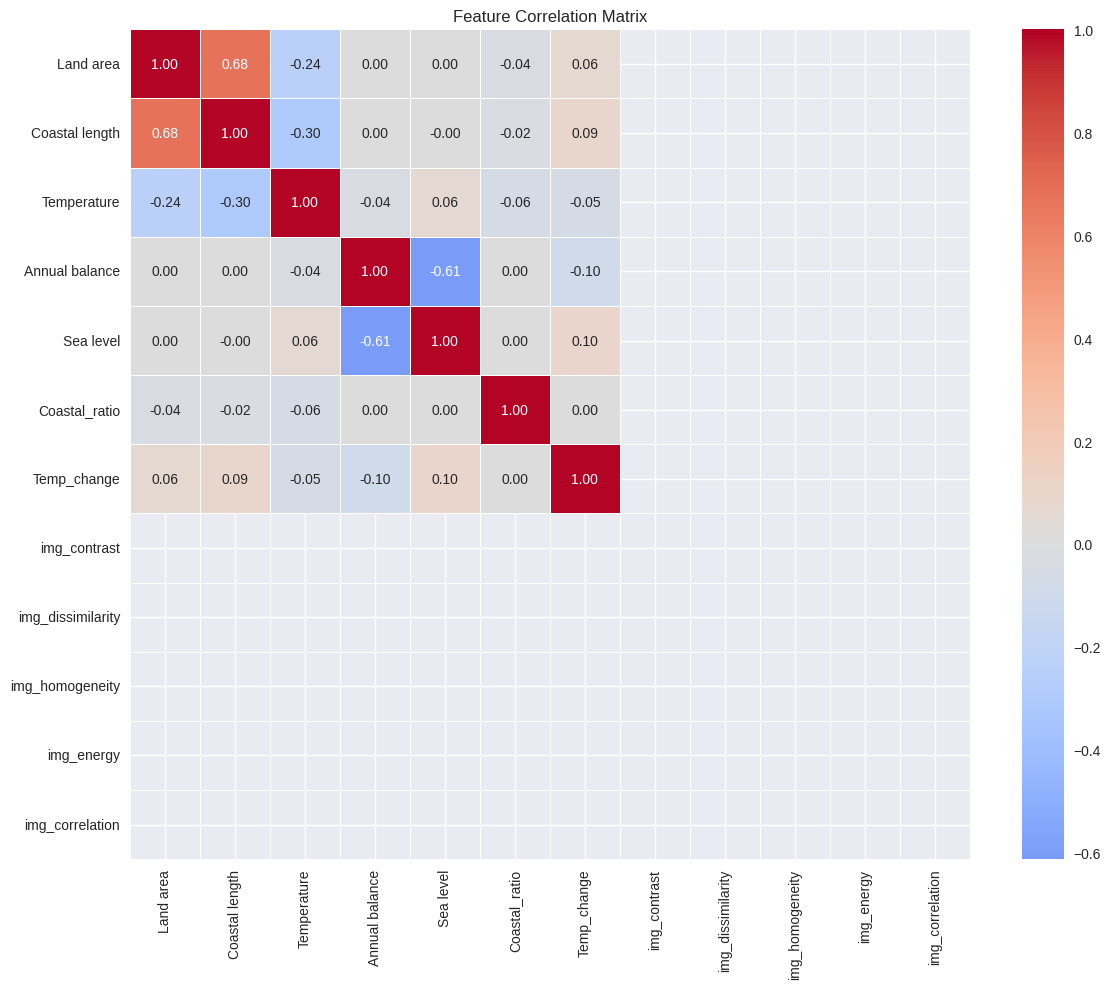

Saved feature correlation plot

Training Tabular-Only model...


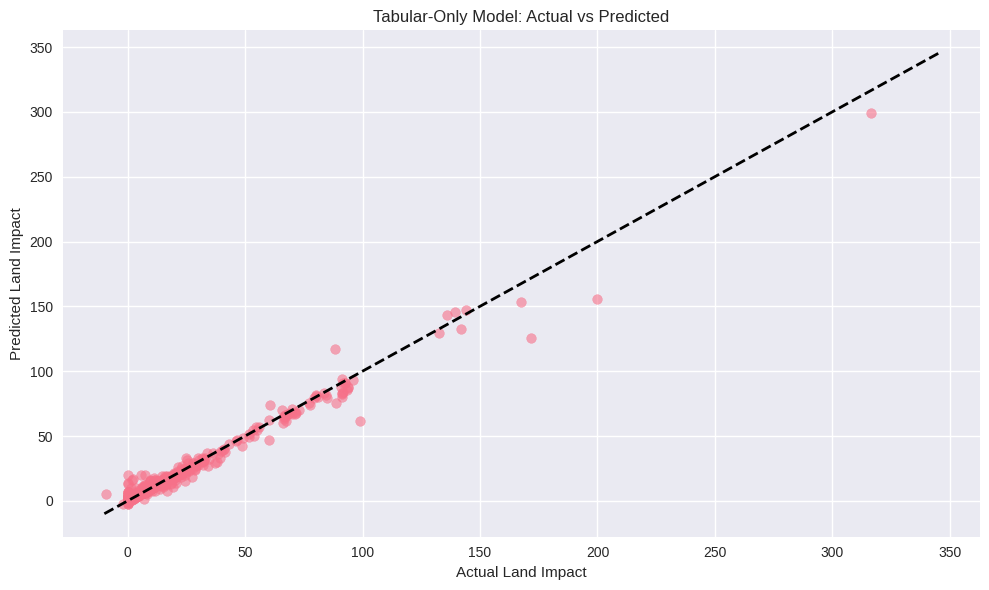

Saved Tabular-Only predictions plot


<Figure size 1200x800 with 0 Axes>

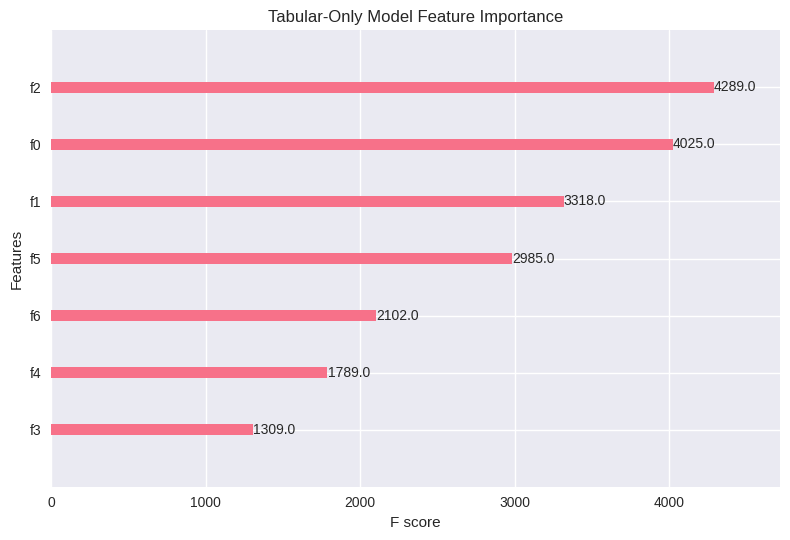

Saved Tabular-Only feature importance plot

Tabular-Only Model Performance:
- MSE: 22.0789
- R²: 0.9760

Training Combined model...


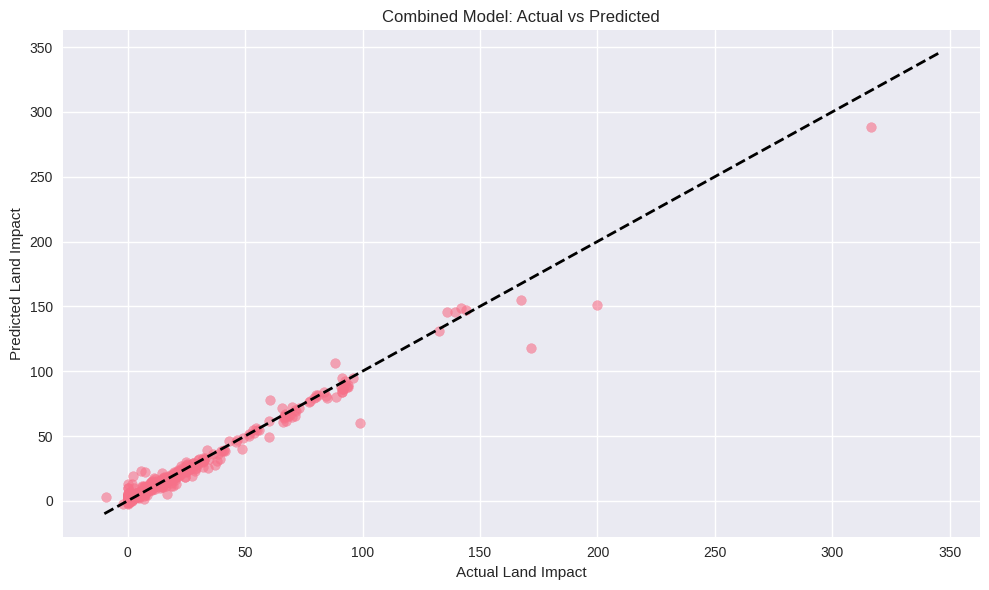

Saved Combined predictions plot


<Figure size 1200x800 with 0 Axes>

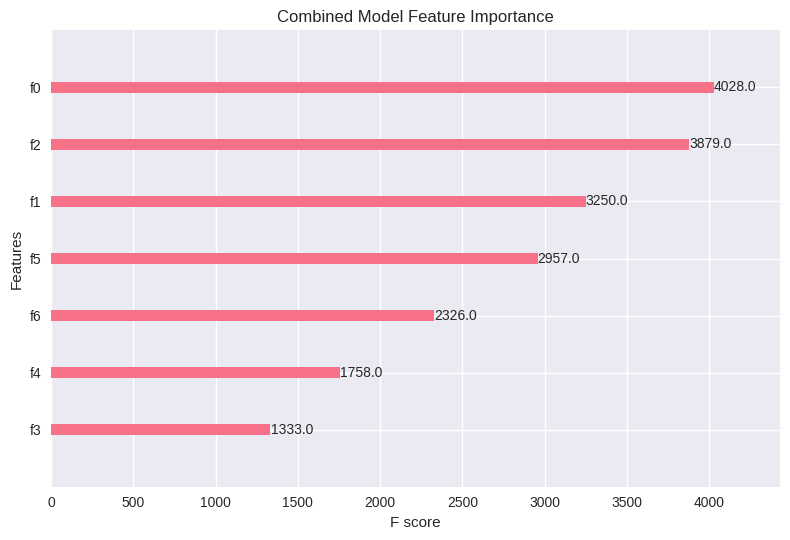

Saved Combined feature importance plot

Combined Model Performance:
- MSE: 23.2747
- R²: 0.9747


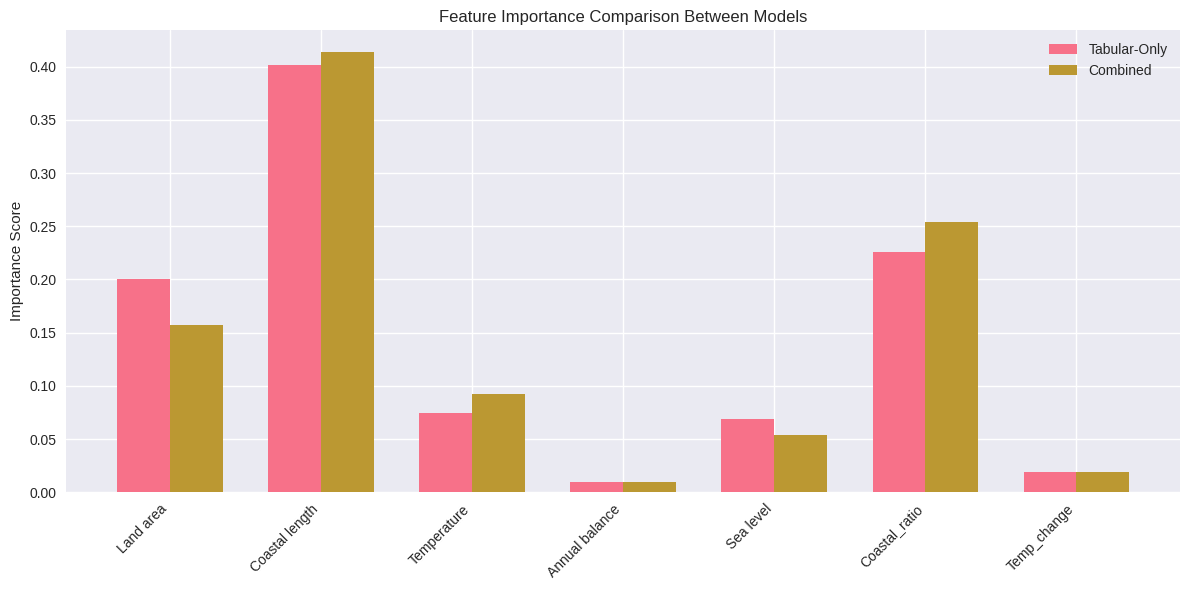

Saved model comparison plot

All visualizations saved to current directory


In [3]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import os

# Set style for all plots
try:
    plt.style.use('seaborn-v0_8')  # Newer seaborn versions
except:
    try:
        plt.style.use('seaborn')  # Older versions
    except:
        plt.style.use('ggplot')  # Fallback style

sns.set_palette("husl")

# 1. Data Loading and Preparation
def load_and_prepare_data(filepath):
    """Load and preprocess the dataset with error handling"""
    try:
        data = pd.read_csv('//content/Land Submergence dataset.csv')

        # Handle missing values
        data['Annual balance'].fillna(data['Annual balance'].mean(), inplace=True)

        # Feature engineering
        data['Coastal_ratio'] = data['Coastal length'] / data['Land area']
        data['Temp_change'] = data.groupby('Country')['Temperature'].diff().fillna(0)

        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Load the dataset
print("Loading data...")
data = load_and_prepare_data('Land_Submergence_dataset.csv')
if data is None:
    raise SystemExit("Failed to load data. Please check the file path.")

# 2. Tabular Feature Preparation
features = ['Land area', 'Coastal length', 'Temperature', 'Annual balance',
            'Sea level', 'Coastal_ratio', 'Temp_change']
target = 'Land Impact'

X = data[features]
y = data[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Visualization: Feature Distributions
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()
plt.close()
print("Saved feature distributions plot")


# 4. Image Feature Processing
def get_image_features(data, expected_samples):
    """Process aerial images with comprehensive error handling"""
    try:
        import cv2
        from skimage.feature import graycomatrix, graycoprops

        image_features = []
        image_dir = 'aerial_images'
        processed_count = 0

        os.makedirs(image_dir, exist_ok=True)

        sample_images = []
        for country in data['Country']:
            img_path = os.path.join(image_dir, f"{str(country).lower().replace(' ', '_')}.jpg")

            if os.path.exists(img_path):
                try:
                    img = cv2.imread(img_path)
                    if img is None:
                        raise ValueError(f"Could not read image at {img_path}")

                    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    gray_img = cv2.resize(gray_img, (256, 256))

                    # Store first 3 sample images for visualization
                    if len(sample_images) < 3:
                        sample_images.append(gray_img)

                    glcm = graycomatrix(gray_img, distances=[5], angles=[0], levels=256,
                                      symmetric=True, normed=True)
                    features = [
                        graycoprops(glcm, 'contrast')[0, 0],
                        graycoprops(glcm, 'dissimilarity')[0, 0],
                        graycoprops(glcm, 'homogeneity')[0, 0],
                        graycoprops(glcm, 'energy')[0, 0],
                        graycoprops(glcm, 'correlation')[0, 0]
                    ]
                    processed_count += 1
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
                    features = [0] * 5
            else:
                features = [0] * 5

            image_features.append(features)

        print(f"\nSuccessfully processed {processed_count}/{len(data)} images")

        # Plot sample images if available
        if sample_images:
            plt.figure(figsize=(15, 5))
            for i, img in enumerate(sample_images):
                plt.subplot(1, 3, i+1)
                plt.imshow(img, cmap='gray')
                plt.axis('off')
            plt.suptitle('Sample Processed Aerial Images')
            plt.tight_layout()
            plt.savefig('sample_aerial_images.png')
            plt.show()
            plt.close()
            print("Saved sample aerial images plot")

        return np.array(image_features)

    except ImportError:
        print("\nWarning: OpenCV or scikit-image not installed. Using tabular data only.")
        return np.zeros((expected_samples, 5))
    except Exception as e:
        print(f"\nImage processing error: {str(e)}")
        return np.zeros((expected_samples, 5))

# Get image features
n_samples = X_scaled.shape[0]
image_features = get_image_features(data, n_samples)

# 5. Feature Combination
try:
    if X_scaled.shape[0] != image_features.shape[0]:
        raise ValueError(f"Dimension mismatch: {X_scaled.shape[0]} tabular samples vs {image_features.shape[0]} image samples")

    X_combined = np.hstack((X_scaled, image_features))
    print(f"\nFeature shapes: Tabular {X_scaled.shape}, Images {image_features.shape}, Combined {X_combined.shape}")

    # Plot feature correlation matrix
    combined_features = features + ['img_contrast', 'img_dissimilarity',
                                  'img_homogeneity', 'img_energy', 'img_correlation']
    combined_df = pd.DataFrame(X_combined, columns=combined_features)

    plt.figure(figsize=(12, 10))
    sns.heatmap(combined_df.corr(), annot=True, fmt=".2f", cmap='coolwarm',
                center=0, linewidths=.5)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.savefig('feature_correlation.png')
    plt.show()
    plt.close()
    print("Saved feature correlation plot")


except ValueError as e:
    print(f"\nError combining features: {str(e)}")
    print("Using tabular data only as fallback")
    X_combined = X_scaled

# 6. Model Training and Evaluation
def train_and_evaluate(X, y, model_name=""):
    """Train and evaluate model with visualization"""
    try:
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Initialize model
        model = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            random_state=42,
            eval_metric='rmse'
        )

        # Train model
        print(f"\nTraining {model_name} model...")
        try:
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                early_stopping_rounds=50,
                verbose=10
            )

            # Plot training history
            results = model.evals_result()
            plt.figure(figsize=(10, 6))
            plt.plot(results['validation_0']['rmse'], label='Test RMSE')
            plt.xlabel('Boosting Round')
            plt.ylabel('RMSE')
            plt.title(f'{model_name} Model Training History')
            plt.legend()
            plt.tight_layout()
            plt.savefig(f'{model_name.lower()}_training_history.png')
            plt.show()
            plt.close()
            print(f"Saved {model_name} training history plot")


        except:
            model.fit(X_train, y_train)

        # Evaluate
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot predictions vs actual
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
        plt.xlabel('Actual Land Impact')
        plt.ylabel('Predicted Land Impact')
        plt.title(f'{model_name} Model: Actual vs Predicted')
        plt.tight_layout()
        plt.savefig(f'{model_name.lower()}_predictions.png')
        plt.show()
        plt.close()
        print(f"Saved {model_name} predictions plot")


        # Plot feature importance
        plt.figure(figsize=(12, 8))
        plot_importance(model, max_num_features=15 if X.shape[1] > 15 else X.shape[1])
        plt.title(f'{model_name} Model Feature Importance')
        plt.tight_layout()
        plt.savefig(f'{model_name.lower()}_feature_importance.png')
        plt.show()
        plt.close()

        print(f"Saved {model_name} feature importance plot")

        print(f"\n{model_name} Model Performance:")
        print(f"- MSE: {mse:.4f}")
        print(f"- R²: {r2:.4f}")

        return model

    except Exception as e:
        print(f"\n{model_name} model training failed: {str(e)}")
        return None

# Train tabular-only model
tabular_model = train_and_evaluate(X_scaled, y, "Tabular-Only")

# Train combined model
combined_model = train_and_evaluate(X_combined, y, "Combined")

# 7. Comparison Visualization
if tabular_model is not None and combined_model is not None:
    # Compare feature importances
    tabular_importance = tabular_model.feature_importances_
    combined_importance = combined_model.feature_importances_[:len(features)]  # Only compare common features

    plt.figure(figsize=(12, 6))
    width = 0.35
    x = np.arange(len(features))

    plt.bar(x - width/2, tabular_importance, width, label='Tabular-Only')
    plt.bar(x + width/2, combined_importance, width, label='Combined')

    plt.xticks(x, features, rotation=45, ha='right')
    plt.ylabel('Importance Score')
    plt.title('Feature Importance Comparison Between Models')
    plt.legend()
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()
    plt.close()
    print("Saved model comparison plot")


print("\nAll visualizations saved to current directory")